In [47]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [66]:
current_path = os.getcwd()
data1_path=current_path+"\\data\\house-prices.csv"
data2_path=current_path+"\\data\\house_price_regression.xlsx"

In [49]:
def find_suitable_font():
    """查找系统中可用的中文字体"""
    chinese_fonts = ['SimHei', 'WenQuanYi Micro Hei', 'Heiti TC', 
                    'Microsoft YaHei', 'SimSun', 'WenQuanYi Micro Hei',
                    'Heiti TC', 'Arial Unicode MS']
    
    for font in chinese_fonts:
        if font in [f.name for f in fm.fontManager.ttflist]:
            return font
    return None  # 如果没有找到任何中文字体

In [50]:
def load_and_preprocess_data(file_path):
    """加载并预处理数据"""
    try:
        # 尝试读取 Excel 文件
        excel_file = pd.ExcelFile(file_path)
        sheet_names = excel_file.sheet_names
        
        if not sheet_names:
            raise ValueError("Excel 文件中没有工作表")
            
        # 获取第一个工作表
        df = excel_file.parse(sheet_names[0])
        
        # 提取 age 列中的数字
        df['age'] = df['age'].str.extract('(\d+)').astype(float)
        
        print(f"成功加载数据，包含 {len(df)} 行 {len(df.columns)} 列")
        return df
        
    except Exception as e:
        print(f"加载数据时出错: {e}")
        return None

<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bcg28\AppData\Local\Temp\ipykernel_21996\2149636876.py:15: SyntaxWarning: invalid escape sequence '\d'
  df['age'] = df['age'].str.extract('(\d+)').astype(float)


In [51]:
def perform_regression_analysis(df, feature_cols, target_col):
    """执行回归分析"""
    if df is None:
        return None, None, None, None, None, None, None
    
    # 提取特征和目标变量
    X = df[feature_cols]
    y = df[target_col]
    
    # 构建线性回归模型
    model = LinearRegression()
    model.fit(X, y)
    
    # 模型预测
    y_pred = model.predict(X)
    
    # 模型评估
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    
    # 计算残差
    residuals = y - y_pred
    
    return model, X, y, y_pred, residuals, r2, mse

In [52]:
def visualize_results(model, X, y, y_pred, residuals, r2, mse, feature_names, target_name):
    """可视化回归分析结果"""
    # 设置matplotlib
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['axes.unicode_minus'] = False  # 确保负号正确显示
    
    # 查找可用中文字体
    font = find_suitable_font()
    if font:
        print(f"找到可用中文字体: {font}")
        plt.rcParams['font.family'] = font
    else:
        print("未找到中文字体，将使用系统默认字体。如果显示异常，请手动安装中文字体。")
    
    # 创建画布
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # 绘制实际值与预测值的散点图
    scatter1 = ax1.scatter(y, y_pred, alpha=0.7, color='dodgerblue')
    ax1.set_xlabel(f'实际{target_name}', fontsize=12)
    ax1.set_ylabel(f'预测{target_name}', fontsize=12)
    ax1.set_title(f'{target_name}实际值与预测值对比', fontsize=14, pad=10)
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # 添加拟合线
    fit_line = ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    ax1.legend([scatter1, fit_line[0]], ['数据点', '理想拟合线'], loc='upper left')

    # 绘制残差图
    scatter2 = ax2.scatter(y_pred, residuals, alpha=0.7, color='salmon')
    ax2.axhline(y=0, color='r', linestyle='--', lw=2)
    ax2.set_xlabel(f'预测{target_name}', fontsize=12)
    ax2.set_ylabel('残差', fontsize=12)
    ax2.set_title('残差图', fontsize=14, pad=10)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    # 添加统计信息文本
    stats_text = f'R² = {r2:.4f}\nMSE = {mse:.2e}'
    ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 添加回归方程文本
    equation_text = f'{target_name} = {model.intercept_:.2f}'
    for i, coef in enumerate(model.coef_):
        equation_text += f' + {coef:.2f}*{feature_names[i]}'
    
    plt.figtext(0.5, 0.01, equation_text, ha="center", fontsize=10, 
                bbox={"facecolor":"white", "alpha":0.5, "pad":5})

    # 调整布局
    plt.tight_layout(pad=3.0)  # 增加子图之间的间距
    plt.subplots_adjust(top=0.85, bottom=0.15)  # 调整顶部和底部间距

    plt.show()

In [53]:
def main(file_path, feature_cols, target_col, feature_names=None):
    """主函数，整合整个分析流程"""
    # 加载数据
    df = load_and_preprocess_data(file_path)
    
    # 执行回归分析
    model, X, y, y_pred, residuals, r2, mse = perform_regression_analysis(
        df, feature_cols, target_col
    )
    
    if model is None:
        print("无法执行回归分析")
        return
    
    # 输出回归系数和截距
    print('\n回归分析结果:')
    print('回归系数：')
    for i, (col, coef) in enumerate(zip(feature_cols, model.coef_)):
        name = feature_names[i] if feature_names else col
        print(f'  {name}: {coef}')
    print(f'截距：{model.intercept_}')
    print(f'R 平方值：{r2}')
    print(f'均方误差：{mse}')
    
    # 可视化结果
    names = feature_names if feature_names else feature_cols
    visualize_results(model, X, y, y_pred, residuals, r2, mse, names, target_col)

成功加载数据，包含 2792 行 9 列

回归分析结果:
回归系数：
  房屋面积: 65103.761225248374
  建筑年代: -3154.135168862462
截距：6272005.194019083
R 平方值：0.8313556404895485
均方误差：967899971176.5935
找到可用中文字体: SimHei


C:\Users\bcg28\AppData\Local\Temp\ipykernel_21996\414386298.py:51: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout(pad=3.0)  # 增加子图之间的间距
G:\AllCodes\VScodes\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


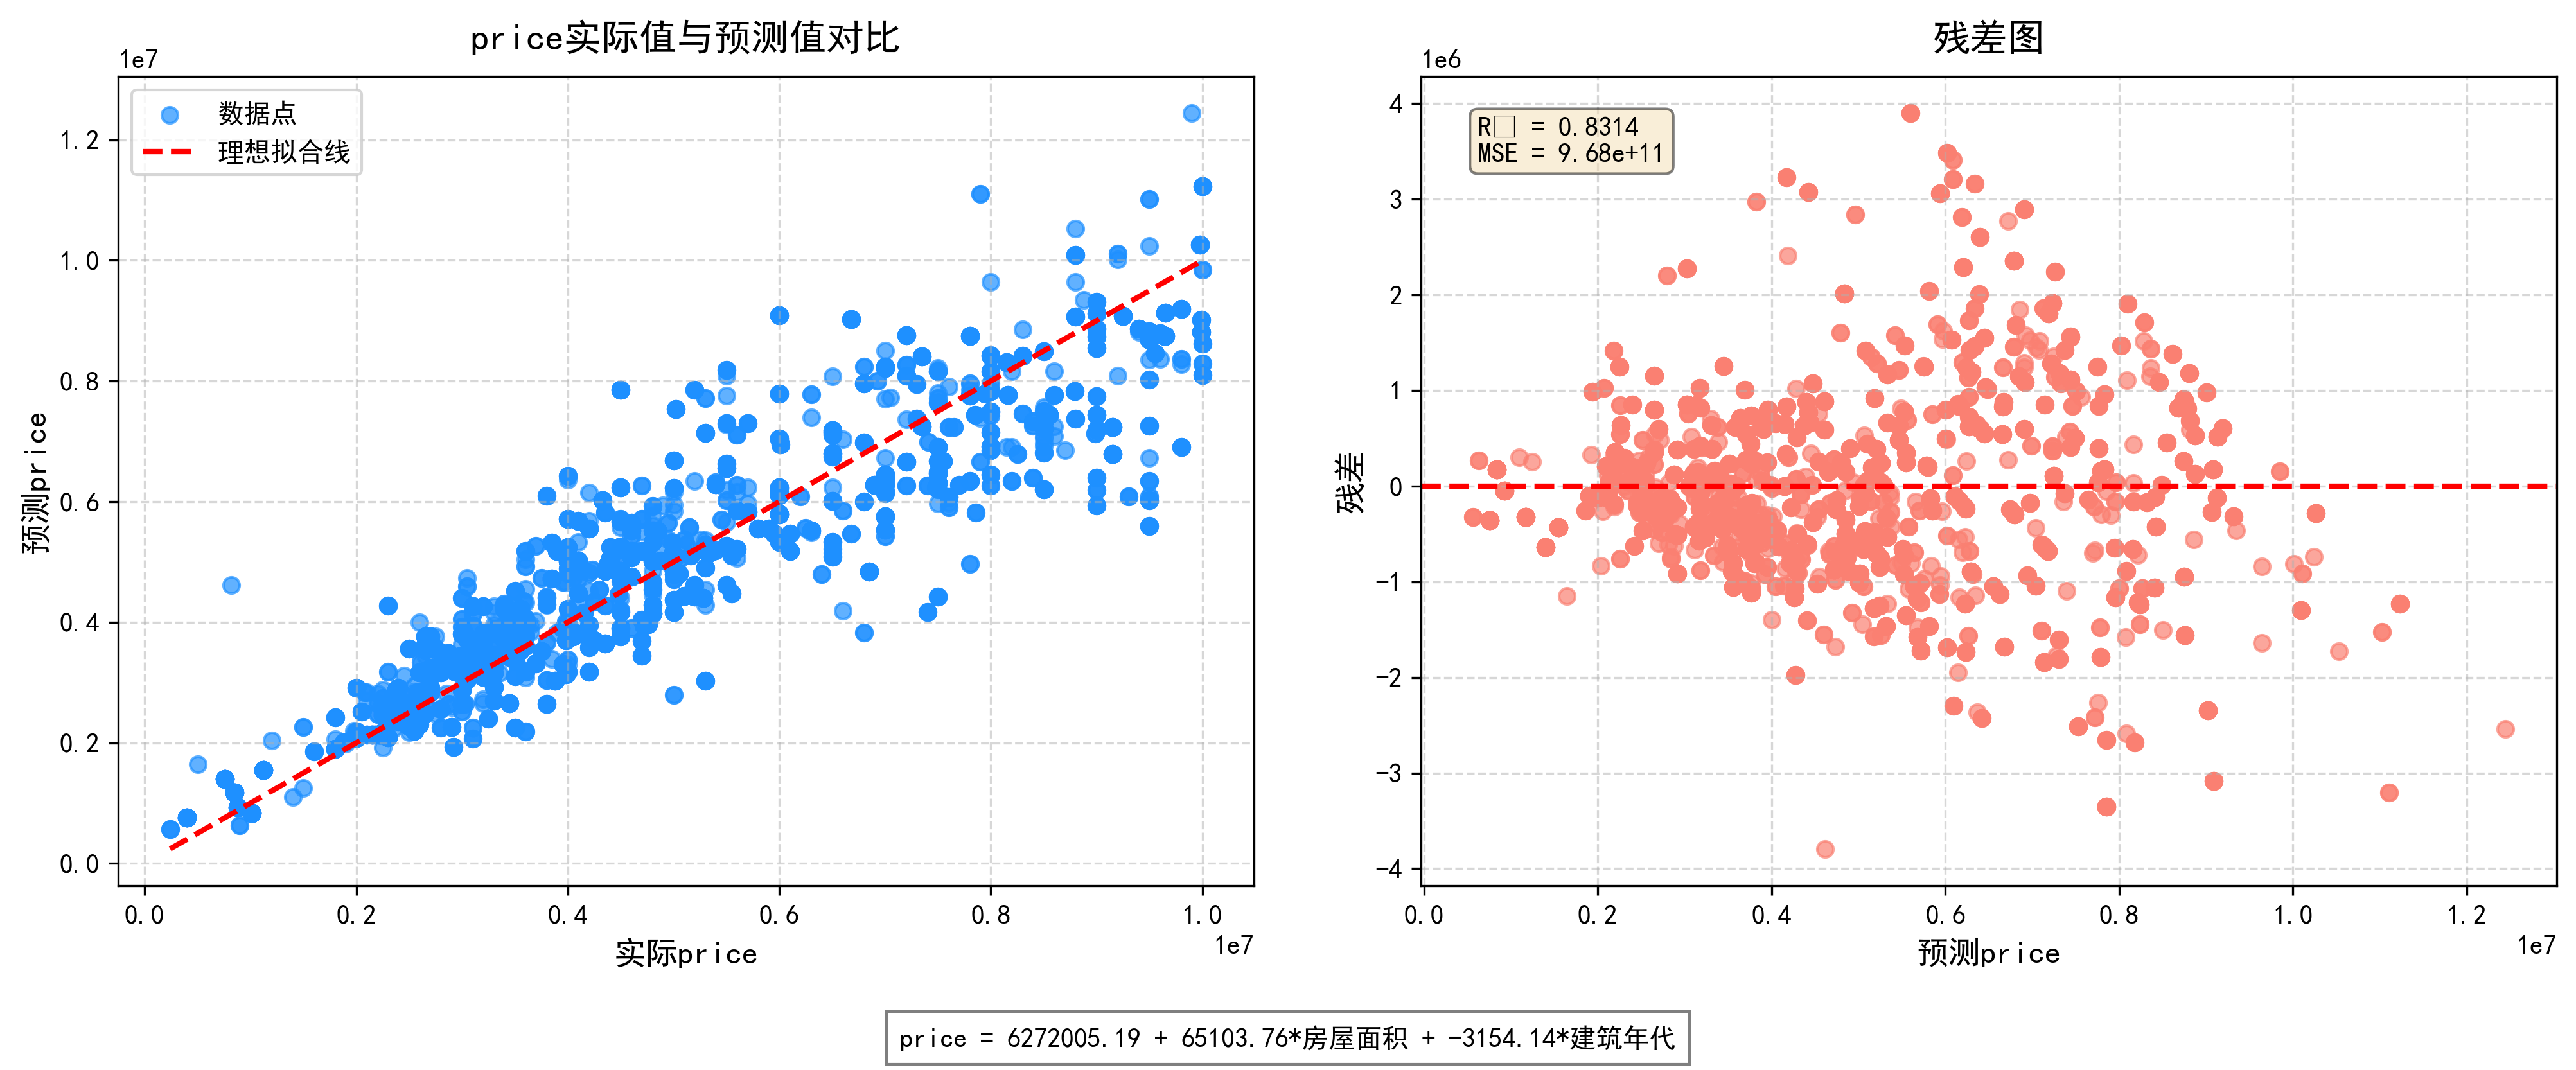

In [54]:
if __name__ == "__main__":
    # 配置参数
    
    FILE_PATH = data2_path  # 请替换为实际文件路径
    FEATURE_COLS = ['area', 'age']  # 特征列
    TARGET_COL = 'price'  # 目标列
    FEATURE_NAMES = ['房屋面积', '建筑年代']  # 特征名称（用于可视化）
    
    main(FILE_PATH, FEATURE_COLS, TARGET_COL, FEATURE_NAMES)

In [58]:
def regression_analysis_and_visualization(file_path):
    # 尝试查找系统中可用的中文字体
    font = find_suitable_font()
    
    # 设置matplotlib
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['axes.unicode_minus'] = False  # 确保负号正确显示
    
    if font:
        print(f"找到可用中文字体: {font}")
        plt.rcParams['font.family'] = font
    else:
        print("未找到中文字体，将使用系统默认字体。如果显示异常，请手动安装中文字体。")
    
    # 加载数据集
    df = pd.read_csv(file_path,encoding='utf-8', skip_blank_lines=True)

    # 提取特征和目标变量
    X = df[['SqFt', 'Bedrooms', 'Bathrooms', 'Offers']]
    y = df['Price']

    # 构建线性回归模型
    model = LinearRegression()
    model.fit(X, y)

    # 模型预测
    y_pred = model.predict(X)

    # 模型评估
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)

    # 输出回归系数和截距
    print('回归系数：', model.coef_)
    print('截距：', model.intercept_)
    print('R 平方值：', r2)
    print('均方误差：', mse)
    
    # 计算残差（修复：将残差计算移到使用之前）
    residuals = y - y_pred

    # 创建画布
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # 绘制实际值与预测值的散点图
    scatter1 = ax1.scatter(y, y_pred, alpha=0.7, color='dodgerblue')
    ax1.set_xlabel('实际价格', fontsize=12)
    ax1.set_ylabel('预测价格', fontsize=12)
    ax1.set_title('实际价格与预测价格的散点图', fontsize=14, pad=10)
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # 添加拟合线
    fit_line = ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    ax1.legend([scatter1, fit_line[0]], ['数据点', '理想拟合线'], loc='upper left')

    # 绘制残差图
    scatter2 = ax2.scatter(y_pred, residuals, alpha=0.7, color='salmon')
    ax2.axhline(y=0, color='r', linestyle='--', lw=2)
    ax2.set_xlabel('预测价格', fontsize=12)
    ax2.set_ylabel('残差', fontsize=12)
    ax2.set_title('残差图', fontsize=14, pad=10)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    # 添加统计信息文本
    stats_text = f'R² = {r2:.4f}\nMSE = {mse:.2e}'
    ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 调整布局
    plt.tight_layout(pad=3.0)  # 增加子图之间的间距
    plt.subplots_adjust(top=0.85)  # 调整顶部间距

    plt.show()


找到可用中文字体: SimHei
回归系数： [    61.8399461    9319.75260206  12646.3474864  -13601.01141229]
截距： -17347.376948519784
R 平方值： 0.6981823488896375
均方误差： 216189187.66119558


C:\Users\bcg28\AppData\Local\Temp\ipykernel_21996\2160351440.py:70: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout(pad=3.0)  # 增加子图之间的间距
G:\AllCodes\VScodes\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


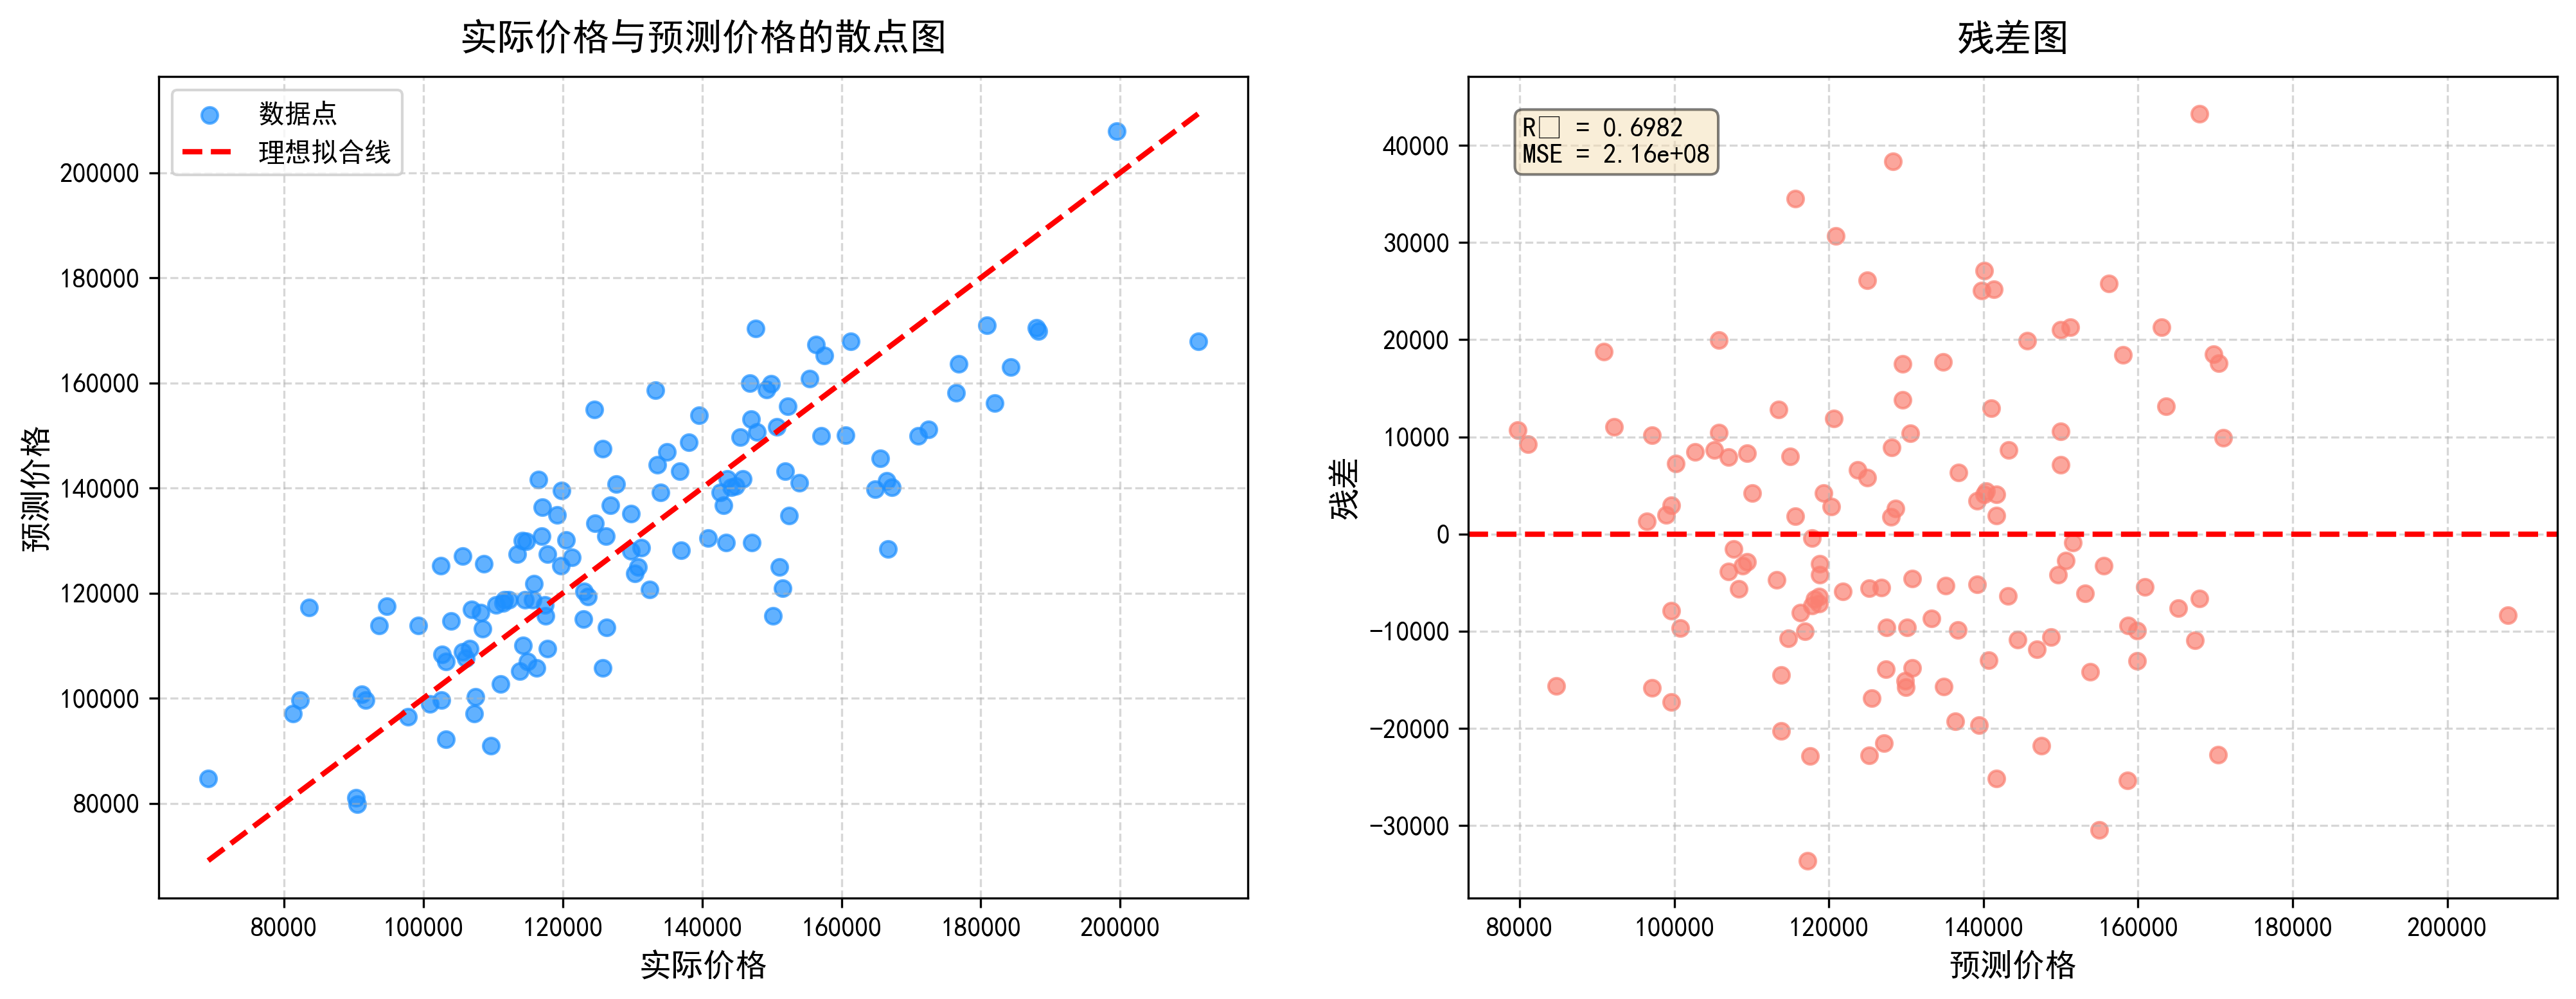

In [67]:
regression_analysis_and_visualization(data1_path)